In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [9]:
q = np.random.rand(100,3)
k = np.random.rand(100,3)


In [10]:
z = q @ k.T
z.shape

(100, 100)

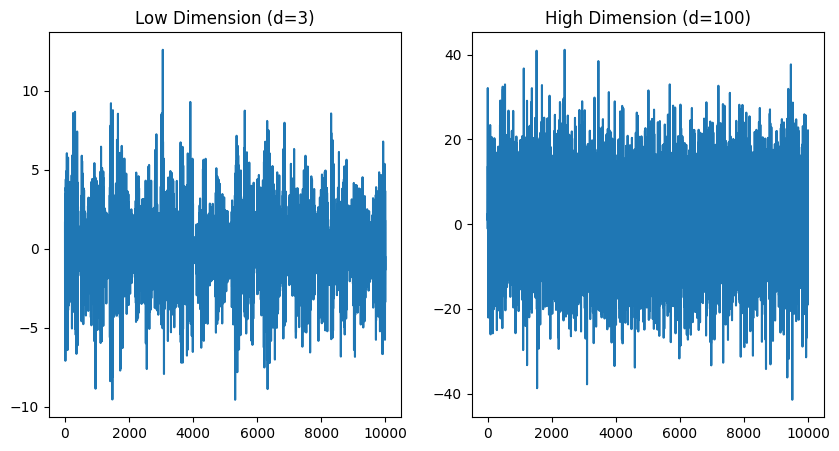

In [19]:
import numpy as np
import matplotlib.pyplot as plt

n = 100

# Low dimension
d_low = 3
q_low = np.random.randn(n, d_low)
k_low = np.random.randn(n, d_low)
z_low = q_low @ k_low.T

# High dimension
d_high = 100
q_high = np.random.randn(n, d_high)
k_high = np.random.randn(n, d_high)
z_high = q_high @ k_high.T



plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.plot(z_low.flatten())
plt.title("Low Dimension (d=3)")

plt.subplot(1,2,2)
plt.plot(z_high.flatten())
plt.title("High Dimension (d=100)")

plt.show()

In [18]:
z_low.flatten()

array([ 0.64104863,  1.42000359, -0.1628105 , ...,  0.56538394,
        1.00219888,  1.26096791])

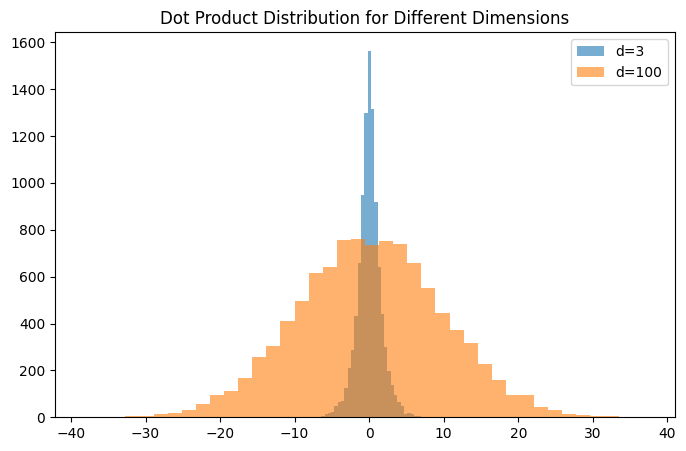

In [14]:
plt.figure(figsize=(8,5))

plt.hist(z_low.flatten(), bins=40, alpha=0.6, label="d=3")
plt.hist(z_high.flatten(), bins=40, alpha=0.6, label="d=100")

plt.legend()
plt.title("Dot Product Distribution for Different Dimensions")
plt.show()

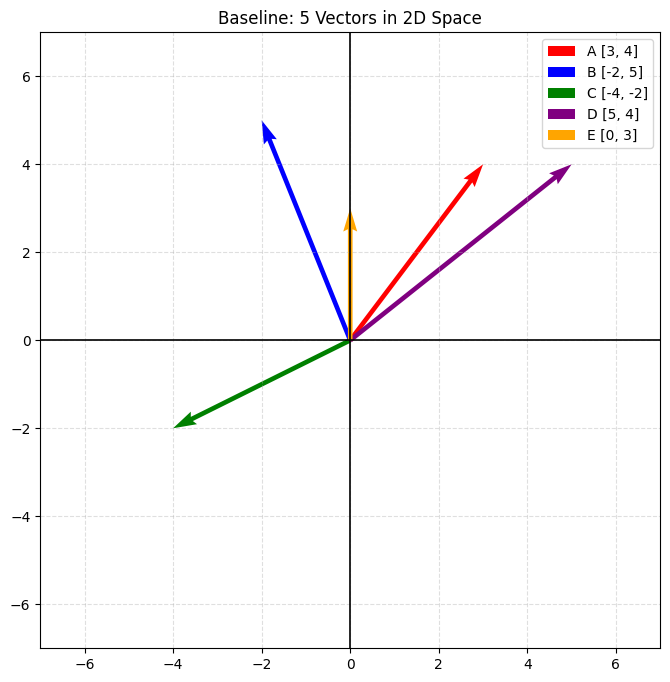

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the 5 vectors
# We use NumPy arrays because this is exactly how data is structured before entering a neural network
vectors = {
    "A": np.array([3, 4]),
    "B": np.array([-2, 5]),
    "C": np.array([-4, -2]),
    "D": np.array([5, 4]),
    "E": np.array([0, 3])
}
colors = ['red', 'blue', 'green', 'purple', 'orange']

# 2. Set up the canvas
plt.figure(figsize=(8, 8))
ax = plt.gca()

# All vectors will originate from the origin (0,0) for this baseline analysis
origin = np.array([0, 0]) 

# 3. Plot the vectors
for (name, vec), color in zip(vectors.items(), colors):
    # plt.quiver takes (X, Y, U, V) -> Origin X, Origin Y, Direction X, Direction Y
    ax.quiver(origin[0], origin[1], vec[0], vec[1], 
              angles='xy', scale_units='xy', scale=1, 
              color=color, label=f'{name} {vec.tolist()}')

# 4. Format the grid to make the geometric analysis clear
plt.xlim(-7, 7)
plt.ylim(-7, 7)

# Draw the x and y axes
plt.axhline(0, color='black', linewidth=1.2)
plt.axvline(0, color='black', linewidth=1.2)

# Add grid lines for easy visualization of magnitudes
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.title("Baseline: 5 Vectors in 2D Space")

# 5. Render
plt.show()

In [30]:
vectors['B'] @ vectors['D'].T

np.int64(10)

In [50]:
x = np.array([[1, 3, 7]])
exp = np.exp(x)
probs = exp / np.sum(exp, axis=1, keepdims=True)
print("exp: ", exp)
print("probs: ", probs*100)

exp:  [[   2.71828183   20.08553692 1096.63315843]]
probs:  [[ 0.2428258   1.79425348 97.96292072]]


In [2]:
import torch
import math
import torch.nn.functional as F

In [3]:
# 1. Setup the dimensions
d_k = 512  # Standard dimension from the "Attention is All You Need" paper
seq_len = 1000 # Number of tokens

# Create Q and K matrices with mean=0 and variance=1 (standard normal distribution)
Q = torch.randn(seq_len, d_k)
K = torch.randn(seq_len, d_k)


In [4]:
print(f"Mean of Q: {Q.mean().item():.4f}")
print(f"Variance of Q: {Q.var().item():.4f}")
print(f"Mean of K: {K.mean().item():.4f}\n")
print(f"Variance of K: {K.var().item():.4f}\n")

Mean of Q: -0.0008
Variance of Q: 0.9983
Mean of K: 0.0007

Variance of K: 0.9977



In [ ]:
plt.hist(Q.reshape(1,-1), bins=40, alpha=0.6, label="d=100")


In [11]:
unscaled_scores = torch.matmul(Q, K.transpose(0, 1)) 

print(f"Expected Variance (d_k): {d_k}")
print(f"Actual Variance of Unscaled Scores: {unscaled_scores.var().item():.4f}\n")


Expected Variance (d_k): 512
Actual Variance of Unscaled Scores: 511.2245



In [16]:
torch.mean(unscaled_scores)

tensor(-0.0098)

In [17]:
scaled_scores = unscaled_scores / math.sqrt(d_k)

print(f"--- The Solution: Scaled Variance ---")
print(f"Expected Variance: 1.0")
print(f"Actual Variance of Scaled Scores: {scaled_scores.var().item():.4f}\n")

--- The Solution: Scaled Variance ---
Expected Variance: 1.0
Actual Variance of Scaled Scores: 0.9985



In [1]:




# 4. Why this matters: The Softmax Saturation
# Let's look at the first row of scores before and after softmax
unscaled_probs = F.softmax(unscaled_scores[0], dim=0)
scaled_probs = F.softmax(scaled_scores[0], dim=0)

print(f"--- The Softmax Effect (Max Probability) ---")
print(f"Max probability in unscaled softmax: {unscaled_probs.max().item():.4f} (Approaching 1.0, meaning gradients vanish)")
print(f"Max probability in scaled softmax:   {scaled_probs.max().item():.4f} (Smoother distribution, healthy gradients)")

--- Initial State ---
Variance of Q: 1.0011
Variance of K: 0.9980

--- The Problem: Exploding Variance ---
Expected Variance (d_k): 512
Actual Variance of Unscaled Scores: 511.5373

--- The Solution: Scaled Variance ---
Expected Variance: 1.0
Actual Variance of Scaled Scores: 0.9991

--- The Softmax Effect (Max Probability) ---
Max probability in unscaled softmax: 0.9982 (Approaching 1.0, meaning gradients vanish)
Max probability in scaled softmax:   0.0106 (Smoother distribution, healthy gradients)


In [25]:
import numpy as np
import matplotlib.pyplot as plt
import math

ax:  Axes(0.125,0.11;0.775x0.77)


Text(0.5, 1.0, 'Original Input Space (X)')

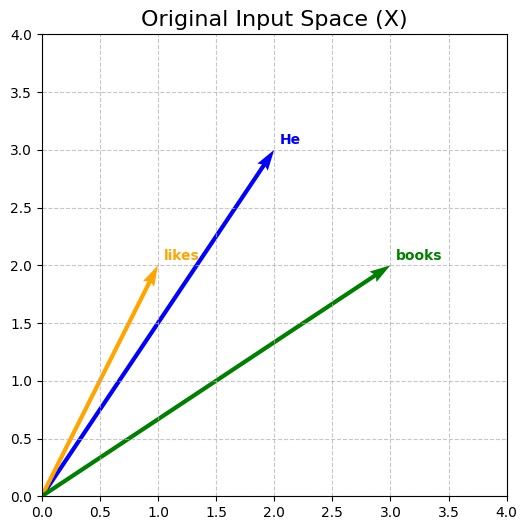

In [19]:

words = ['He', 'likes', 'books']
X = np.array([
    [2, 3],  # He
    [1, 2],  # likes
    [3, 2]   # books
])

fig, ax = plt.subplots(figsize=(6, 6))
colors = ['blue', 'orange', 'green']

print("ax: ", ax)
# Plot each vector from origin (0,0)
for i, (x, y) in enumerate(X):
    ax.quiver(0, 0, x, y, angles='xy', scale_units='xy', scale=1, color=colors[i], width=0.009)
    ax.text(x + 0.05, y + 0.05, words[i], fontsize=10, fontweight='bold', color=colors[i])

ax.set_xlim(0, 4)
ax.set_ylim(0, 4)
ax.grid(True, linestyle='--', alpha=0.7)
ax.set_title("Original Input Space (X)", fontsize=16)



In [13]:
print("He.Likes: ", X[0] @ X[1])
print("He.Books: ", X[0] @ X[2])
print("Likes.Books: ", X[1] @ X[2])

He.Likes:  8
He.Books:  12
Likes.Books:  7


In [14]:
import numpy as np

X = np.array([
    [2, 3],  # He
    [1, 2],  # likes
    [3, 2]   # books
])

def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

print(f"Cosine(He, likes): {cosine_sim(X[0], X[1]):.4f}")
print(f"Cosine(He, books): {cosine_sim(X[0], X[2]):.4f}")
print(f"Cosine(likes, books): {cosine_sim(X[1], X[2]):.4f}")

Cosine(He, likes): 0.9923
Cosine(He, books): 0.9231
Cosine(likes, books): 0.8682


In [15]:
Wq = np.array([[1,1], [0,1]])
Wk = np.array([[1,0], [1,1]])
Wv = np.array([[1,0], [1,0]])

ax:  Axes(0.125,0.11;0.775x0.77)
Emb:  [[2.9716587  2.9716587 ]
 [2.89152364 2.89152364]
 [2.97158591 2.97158591]]


Text(0.5, 1.0, 'Original Input Space (X)')

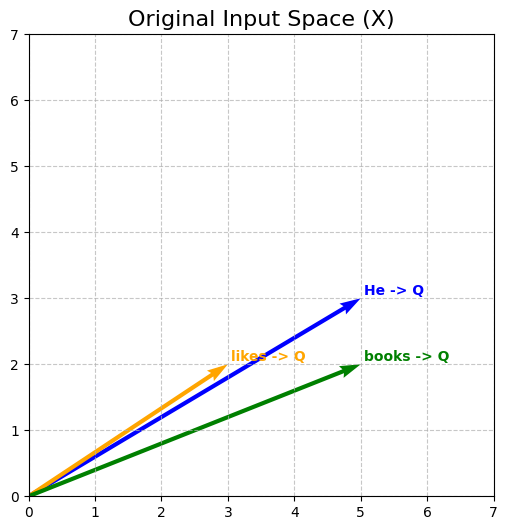

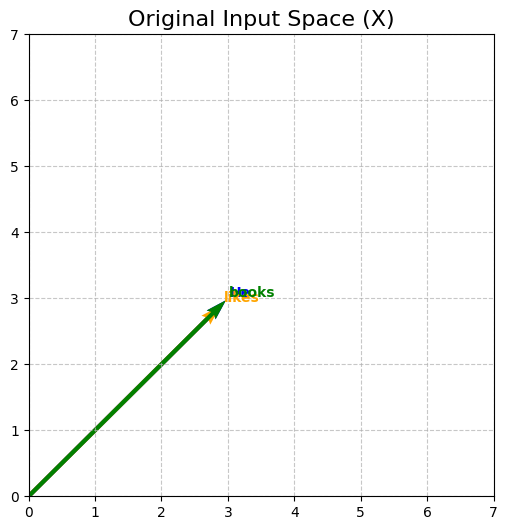

In [41]:
Q = X@Wq.T
K = X@Wk.T
V = X@Wv.T


words = ['He -> Q', 'likes -> Q', 'books -> Q']
fig, ax = plt.subplots(figsize=(6, 6))
colors = ['blue', 'orange', 'green']

print("ax: ", ax)
# Plot each vector from origin (0,0)
for i, (x, y) in enumerate(Q):
    ax.quiver(0, 0, x, y, angles='xy', scale_units='xy', scale=1, color=colors[i], width=0.009)
    ax.text(x + 0.05, y + 0.05, words[i], fontsize=10, fontweight='bold', color=colors[i])

ax.set_xlim(0, 7)
ax.set_ylim(0, 7)
ax.grid(True, linestyle='--', alpha=0.7)
ax.set_title("Original Input Space (X)", fontsize=16)


score = (Q@K.T/ math.sqrt(K.shape[1]))
exp = np.exp(score) 

probs = exp / np.sum(exp, axis = 1, keepdims=True)
emb = probs @ V

print("Emb: ",emb)
words = ['He', 'likes', 'books']
fig, ax = plt.subplots(figsize=(6, 6))
colors = ['blue', 'orange', 'green']

# Plot each vector from origin (0,0)
for i, (x, y) in enumerate(emb):
    ax.quiver(0, 0, x, y, angles='xy', scale_units='xy', scale=1, color=colors[i], width=0.009)
    ax.text(x + 0.05, y + 0.05, words[i], fontsize=10, fontweight='bold', color=colors[i])

ax.set_xlim(0, 7)
ax.set_ylim(0, 7)
ax.grid(True, linestyle='--', alpha=0.7)
ax.set_title("Original Input Space (X)", fontsize=16)

